In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('cmu-sleep.csv')

In [3]:
df.head(10)

,subject_id,study,cohort,demo_race,demo_gender,demo_firstgen,bedtime_mssd,TotalSleepTime,midpoint_sleep,frac_nights_with_data,daytime_sleep,cum_gpa,term_gpa,term_units,Zterm_units_ZofZ
0,185,5,lac1,1,1,0,0.116727,432.200000,458.660000,0.862069,24.160000,3.00,3.38,73,4.055294859
1,158,5,lac1,0,1,0,0.141681,391.931035,364.465517,1.000000,13.137931,3.66,2.60,64,2.482534122
2,209,5,lac1,1,1,0,1.529289,344.304348,560.891304,0.793103,14.956522,3.57,3.07,63,2.30778293
3,102,5,lac1,0,1,1,0.130148,392.620690,416.482759,1.000000,54.551724,3.61,3.56,61,1.958280544
4,174,5,lac1,1,1,0,0.130181,423.421053,368.763158,0.655172,10.526316,3.21,4.00,61,1.958280544
5,184,5,lac1,1,1,0,0.209483,397.400000,353.580000,0.862069,22.360000,3.20,3.36,60,1.783529351
6,255,5,lac1,1,1,0,0.675489,348.592593,434.703704,0.931034,20.518519,3.40,3.19,60,1.783529351
7,265,5,lac1,1,1,0,0.129622,422.111111,414.833333,0.931034,17.037037,3.86,3.28,60,1.783529351
8,343,5,lac1,1,0,0,1.476979,454.321429,423.821429,0.965517,52.678571,3.79,3.50,60,1.783529351
9,137,5,lac1,1,1,0,0.085000,308.965517,334.793103,1.000000,85.482759,3.53,2.55,59,1.608778158


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 634 entries, 0 to 633
Data columns (total 15 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   subject_id             634 non-null    int64  
 1   study                  634 non-null    int64  
 2   cohort                 634 non-null    object 
 3   demo_race              634 non-null    object 
 4   demo_gender            634 non-null    object 
 5   demo_firstgen          634 non-null    object 
 6   bedtime_mssd           634 non-null    float64
 7   TotalSleepTime         634 non-null    float64
 8   midpoint_sleep         634 non-null    float64
 9   frac_nights_with_data  634 non-null    float64
 10  daytime_sleep          634 non-null    float64
 11  cum_gpa                634 non-null    float64
 12  term_gpa               634 non-null    float64
 13  term_units             634 non-null    object 
 14  Zterm_units_ZofZ       634 non-null    object 
dtypes: flo

In [5]:
df['term_units'] = pd.to_numeric(df['term_units'], errors='coerce')
df['Zterm_units_ZofZ'] = pd.to_numeric(df['Zterm_units_ZofZ'], errors='coerce')

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 634 entries, 0 to 633
Data columns (total 15 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   subject_id             634 non-null    int64  
 1   study                  634 non-null    int64  
 2   cohort                 634 non-null    object 
 3   demo_race              634 non-null    object 
 4   demo_gender            634 non-null    object 
 5   demo_firstgen          634 non-null    object 
 6   bedtime_mssd           634 non-null    float64
 7   TotalSleepTime         634 non-null    float64
 8   midpoint_sleep         634 non-null    float64
 9   frac_nights_with_data  634 non-null    float64
 10  daytime_sleep          634 non-null    float64
 11  cum_gpa                634 non-null    float64
 12  term_gpa               634 non-null    float64
 13  term_units             487 non-null    float64
 14  Zterm_units_ZofZ       487 non-null    float64
dtypes: flo

In [6]:
df['term_units'].fillna(df['term_units'].median(), inplace=True)
df['Zterm_units_ZofZ'].fillna(df['Zterm_units_ZofZ'].median(), inplace=True)

C:\Users\akshg\AppData\Local\Temp\ipykernel_27420\3431616260.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['term_units'].fillna(df['term_units'].median(), inplace=True)
C:\Users\akshg\AppData\Local\Temp\ipykernel_27420\3431616260.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as 

In [7]:
df.describe()

,subject_id,study,bedtime_mssd,TotalSleepTime,midpoint_sleep,frac_nights_with_data,daytime_sleep,cum_gpa,term_gpa,term_units,Zterm_units_ZofZ
count,634.000000,634.000000,634.000000,634.000000,634.000000,634.000000,634.000000,634.000000,634.000000,634.000000,634.000000
mean,13005.892744,3.181388,0.451688,397.323874,398.679186,0.867439,41.164241,3.465596,3.449598,26.518927,0.009554
std,26496.593477,1.317125,1.393632,50.856725,72.710945,0.178960,27.389418,0.437577,0.500467,16.321042,0.876399
min,1.000000,1.000000,0.004505,194.782609,247.071429,0.214286,2.269231,1.210000,0.350000,5.000000,-3.982521
25%,178.000000,2.000000,0.074694,366.930077,345.182692,0.821429,23.097826,3.232283,3.233333,15.000000,-0.479501
50%,358.500000,3.000000,0.135007,400.395833,388.245726,0.932184,34.982143,3.557833,3.555667,17.000000,0.041207
75%,592.750000,4.000000,0.291698,430.114583,437.655263,1.000000,51.248538,3.789545,3.810000,45.000000,0.373361
max,99978.000000,5.000000,20.849225,587.666667,724.666667,1.000000,292.304348,4.000000,4.000000,73.000000,4.055295


In [8]:
cols = ['demo_race', 'demo_gender', 'demo_firstgen']

df[cols] = df[cols].replace(r'^\s*$', np.nan, regex=True)
df.dropna(subset=cols, inplace=True)

### Comparison of Term GPA by Demographics

We analyzed how term GPA varies across different demographic groups:

- Gender
- Race
- First-generation status

box plots were created to visualize differences in GPA across these groups.

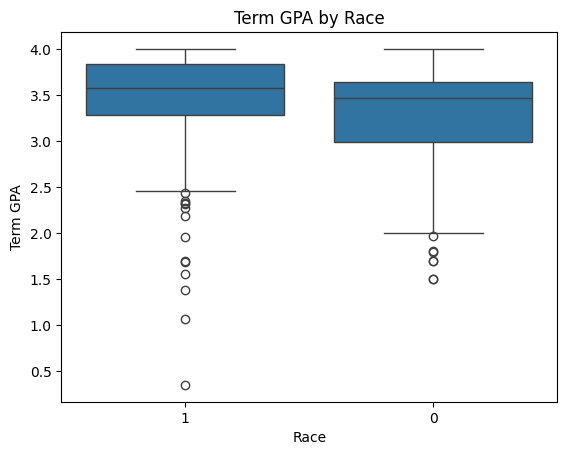

In [9]:
sns.boxplot(x='demo_race', y='term_gpa', data=df)
plt.title('Term GPA by Race')
plt.xlabel('Race')
plt.ylabel('Term GPA')
plt.show()



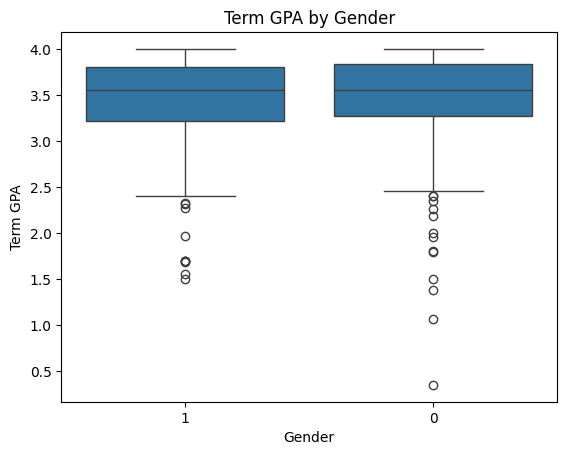

In [10]:
sns.boxplot(x='demo_gender', y='term_gpa', data=df)
plt.title('Term GPA by Gender')
plt.xlabel('Gender')
plt.ylabel('Term GPA')
plt.show()


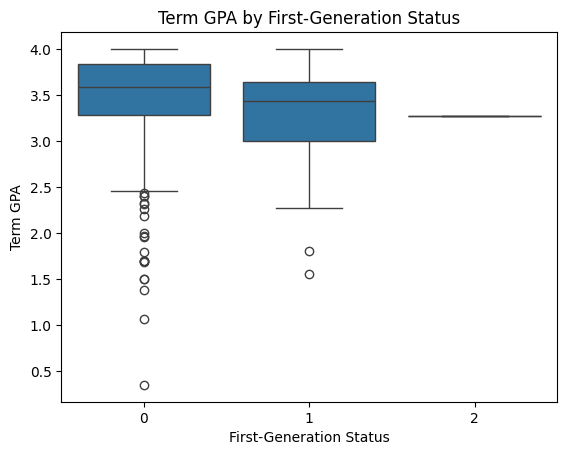

In [25]:
sns.boxplot(x='demo_firstgen', y='term_gpa', data=df)
plt.title('Term GPA by First-Generation Status')
plt.xlabel('First-Generation Status')
plt.ylabel('Term GPA')
plt.show()

#### Visualization Insights

- The plots show very similar GPA distributions across groups
- No major variation is visible between categories
- This suggests demographic factors may not strongly affect GPA in this dataset

### One-Way ANOVA Test (Gender)

To statistically test differences, a one-way ANOVA was performed.

- Null Hypothesis (H₀):
    There is no significant difference in term GPA across gender groups.
- Alternative Hypothesis (H₁):
    There is a significant difference in term GPA across gender groups.

In [12]:
from scipy.stats import f_oneway


groups = [df[df['demo_gender']==g]['term_gpa'] for g in df['demo_gender'].unique()]
f_oneway(*groups)

F_onewayResult(statistic=np.float64(0.005038667652937336), pvalue=np.float64(0.9434335726129017))

F-statistic: 0.005
p-value: 0.943

#### Interpretation
- Since p-value > 0.05, we fail to reject the null hypothesis
- There is no statistically significant difference in term GPA between genders

### One-Way ANOVA Test (Race)

To statistically test differences, a one-way ANOVA was performed.

- Null Hypothesis (H₀):
    There is no significant difference in term GPA across Race groups.
- Alternative Hypothesis (H₁):
    There is a significant difference in term GPA across Race groups.

In [13]:
groups = [df[df['demo_race']==g]['term_gpa'] for g in df['demo_race'].unique()]
f_oneway(*groups)

F_onewayResult(statistic=np.float64(19.29558552905648), pvalue=np.float64(1.3153754275213038e-05))

F-statistic: 19.29
p-value: 0.000013

#### Interpretation
- Since p-value < 0.05, we reject the null hypothesis
- There is statistically significant difference in term GPA between different Race Groups

### One-Way ANOVA Test (First-Generation Status)

To statistically test differences, a one-way ANOVA was performed.

- Null Hypothesis (H₀):
There is no significant difference in term GPA whether a student is first-generation or not.
- Alternative Hypothesis (H₁):
There is a significant difference in term GPA whether a student is first-generation or not.

In [14]:
groups = [df[df['demo_firstgen']==g]['term_gpa'] for g in df['demo_firstgen'].unique()]
f_oneway(*groups)

F_onewayResult(statistic=np.float64(5.90301488273425), pvalue=np.float64(0.0028863005328264016))

F-statistic: 5.90
p-value: 0.0028

#### Interpretation
- Since p-value < 0.05, we reject the null hypothesis
- There is statistically significant difference in term GPA between different Race Groups

### Average Total Sleep Time by Cohort

The average total sleep time was calculated for each cohort using group-wise aggregation.

This helps in understanding differences in sleep patterns across schools.

In [24]:
df.groupby('cohort')['TotalSleepTime'].mean()

cohort
lac1    391.783088
lac2    379.746767
nh      385.624379
uw1     412.673665
uw2     409.506364
Name: TotalSleepTime, dtype: float64

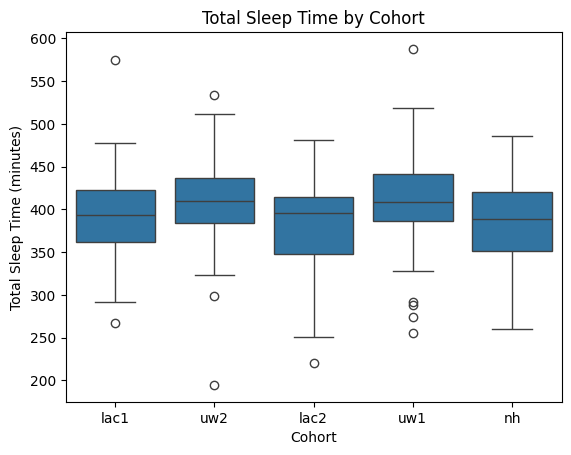

In [16]:
sns.boxplot(x='cohort', y='TotalSleepTime', data=df)
plt.title('Total Sleep Time by Cohort')
plt.xlabel('Cohort')
plt.ylabel('Total Sleep Time (minutes)')
plt.show()

### One-Way ANOVA Test (Total Sleep Time by Cohort)

To examine whether Total Sleep Time differs across different cohorts, a one-way ANOVA test was conducted.

Hypothesis
- Null Hypothesis (H₀):
There is no significant difference in total sleep time across different cohorts.
- Alternative Hypothesis (H₁):
There is a significant difference in total sleep time across different cohorts.

In [17]:
groups = [df[df['cohort']==g]['TotalSleepTime'] for g in df['cohort'].unique()]
f_oneway(*groups)

F_onewayResult(statistic=np.float64(10.28531921053254), pvalue=np.float64(4.540430804824728e-08))

F-statistic: 10.285
p-value: 4.54e-08

#### Interpretation
- Since p-value < 0.05, we reject the null hypothesis
- There is a statistically significant difference in total sleep time across different cohorts

### Linear Regression Analysis

A multiple linear regression was performed to examine the relationship between Total Sleep Time and Term GPA, while controlling for Cumulative GPA.

In [ ]:
import statsmodels.api as sm

X = df[['TotalSleepTime', 'cum_gpa']] 
y = df['term_gpa']                   
X = sm.add_constant(X)
model = sm.OLS(y, X).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:               term_gpa   R-squared:                       0.426
Model:                            OLS   Adj. R-squared:                  0.424
Method:                 Least Squares   F-statistic:                     231.2
Date:                Wed, 25 Mar 2026   Prob (F-statistic):           7.90e-76
Time:                        00:09:21   Log-Likelihood:                -283.41
No. Observations:                 626   AIC:                             572.8
Df Residuals:                     623   BIC:                             586.1
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
const              0.4358      0.162      2.

#### Model Results
R-squared: 0.426
F-statistic p-value: < 0.001 

This indicates that the model is statistically significant and explains about 42.6% of the variance in term GPA.

#### Coefficient Interpretation
- TotalSleepTime (coef = 0.0014, p < 0.001):\
There is a positive and statistically significant relationship between total sleep time and term GPA.
As sleep time increases, GPA slightly increases.
- cum_gpa (coef = 0.7126, p < 0.001):\
Strong positive relationship with term GPA.
Previous academic performance is a major predictor of current GPA.

#### Conclusion

- Total sleep time has a statistically significant positive effect on term GPA, even after controlling for cumulative GPA.

- However, the effect size is small, while cumulative GPA has a much stronger influence.

### Predicting gpa of a student  with 360 minutes of sleep and cum_gpa = 3.0

In [23]:
new_data = pd.DataFrame({
    'TotalSleepTime': [360],
    'cum_gpa': [3.0]
})

# add constant properly
new_data = sm.add_constant(new_data, has_constant='add')

prediction = model.predict(new_data)
print(prediction)

0    3.066756
dtype: float64


#### Interpretation (short)
A student with 360 minutes sleep and cum_gpa = 3.0
Expected term GPA ≈ 3.07

### Final Conclusion

This analysis explored the relationship between sleep patterns and academic performance among students.

- Demographic factors such as gender showed no significant impact on GPA, while race and first-generation status showed statistically significant differences.
- Total sleep time varied significantly across cohorts, indicating differences in sleep behavior between schools.
- A positive and statistically significant relationship was found between total sleep time and term GPA, even after controlling for cumulative GPA. However, the effect of sleep was relatively small compared to prior academic performance.
- The regression model further confirmed that cumulative GPA is the strongest predictor of term GPA.

Overall, while sleep does have a meaningful impact on academic performance, prior academic achievement remains the most influential factor.